# Evaluate classification accuracy

This notebook demonstrates how to evaluate classification accuracy of "novel taxa". Due to the unique nature of this analysis, the metrics that we use to evaluate classification accuracy of "novel taxa" are different from those used for mock and simulated communities.

The key measure here is rate of ``match`` vs. ``overclassification``, hence P/R/F are not useful metrics. Instead, we define and measure the following as percentages:
* Match vs. overclassification rate
    * Match: assignment == L - 1 (e.g., a novel species is assigned the correct genus)
    * overclassification: assignment == L (e.g., correct genus but assigns to a near neighbor)
    * misclassification: incorrect assignment at L - 1 (e.g., wrong genus-level assignment)
    
Where ``L`` = taxonomic level being tested




## Functions

In [14]:
#from tax_credit.taxa_manipulator import *
from tax_credit.framework_functions import (novel_taxa_classification_evaluation,
                                            extract_per_level_accuracy,
                                            per_level_kruskal_wallis)
from tax_credit.eval_framework import (parameter_comparisons,
                                       method_by_dataset)
from tax_credit.plotting_functions import (pointplot_from_data_frame,
                                           heatmap_from_data_frame,)

from os import path, makedirs, remove, rename
from os.path import expandvars, join, exists
from glob import glob
from IPython.display import display

## Evaluate classification results
First, enter in filepaths and directory paths where your data are stored, and the destination

In [3]:
project_dir = expandvars("$HOME/Desktop/projects/short-read-tax-assignment")
analysis_name = "novel-taxa-simulations"
precomputed_results_dir = join(project_dir, "data", "precomputed-results", analysis_name)
expected_results_dir = join(project_dir, "data", analysis_name)
summary_fp = join(precomputed_results_dir, 'evaluate_classification_summary.csv')

results_dirs = glob(join(precomputed_results_dir, '*', '*', '*', '*'))

This cell performs the classification evaluation and should not be modified.

In [4]:
if not exists(summary_fp):
    accuracy_results = novel_taxa_classification_evaluation(results_dirs, expected_results_dir, summary_fp)
else:
    accuracy_results = pd.DataFrame.from_csv(summary_fp)

# Plot classification accuracy
Finally, we plot our results. Line plots show the mean +/- 95% confidence interval for each classification result at each taxonomic level (1 = phylum, 6 = species) in each dataset tested. Do not modify the cell below, except to adjust the color_pallette used for plotting. This palette can be a dictionary of colors for each group, as shown below, or a [seaborn color palette](http://seaborn.pydata.org/tutorial/color_palettes.html).

**match_ratio** = proportion of correct matches. For novel taxa, this means a match at the last common ancestor (level-1)

**overclassification_ratio** = proportion of taxa that were assigned to correct lineage but to a deeper taxonomic level than expected, rather than to LCA. E.g., assignment to another species in the clade

**underclassification_ratio** = proportion of assignments to correct lineage but to a lower level than expected.

**misclassification_ratio** = proportion of assignments to an incorrect lineage.

In [5]:
color_pallette = dict(rdp="seagreen", sortmerna="gray", uclust="blue")

y_vars = ["match_ratio", "overclassification_ratio", 
          "underclassification_ratio", "misclassification_ratio"]

## Plot per-level classification accuracy

For novel-taxa analysis, a separate classification is performed at each taxonomic level using different test (unique taxa at level L) and training sets (ref - test taxonomies). Hence, results at each level L represent independent tests, unlike for mock and simulated communities where each level represents the accuracy of each species-level classification trimmed to level L. For novel taxa, results at level L indicate the accuracy with with method M assigns the correct lineage to a "novel" taxon, which is unrepresented in the reference at level L, e.g., level 6 indicates the performance with which each classifier assigns the correct genus to each species. 

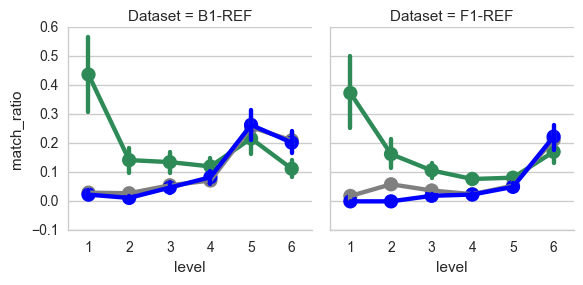

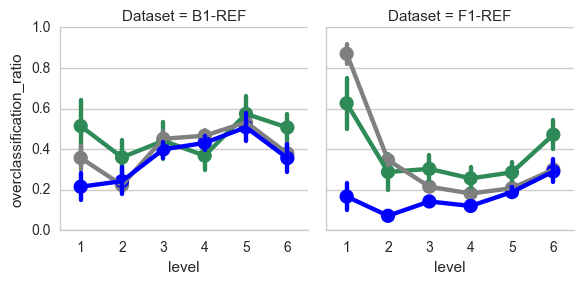

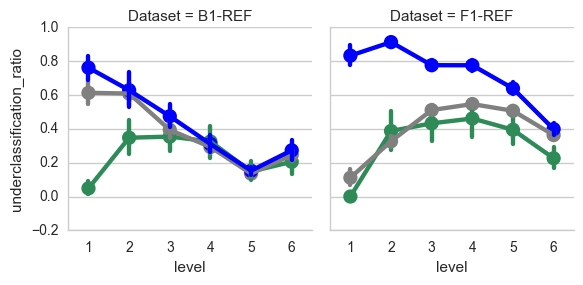

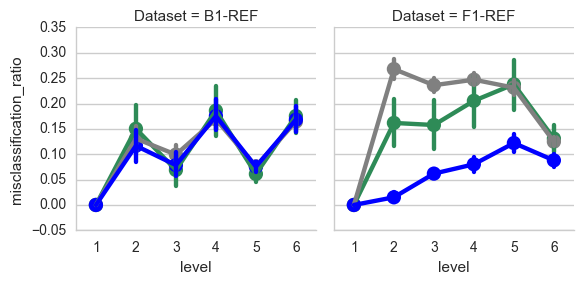

In [6]:
pointplot_from_data_frame(accuracy_results, "level", y_vars, 
                          group_by="Dataset", color_by="Method",
                          color_pallette=color_pallette)

## Per-level classification accuracy statistic
Kruskal-Wallis FDR-corrected p-values comparing classification methods at each level of taxonomic assignment

In [7]:
result = per_level_kruskal_wallis(accuracy_results, y_vars, group_by='Method', 
                                  dataset_col='Dataset', alpha=0.05, 
                                  pval_correction='fdr_bh')
result

,Dataset,Variable,1,2,3,4,5,6
0,B1-REF,match_ratio,7.908965e-11,5.650932e-10,2.680626e-04,2.532276e-02,6.102645e-01,0.003603
1,B1-REF,overclassification_ratio,8.844834e-04,7.041749e-03,2.069644e-01,7.524479e-02,3.770628e-01,0.038896
2,B1-REF,underclassification_ratio,7.561433e-18,3.508293e-04,8.873772e-03,6.994673e-01,2.362193e-01,0.206964
3,B1-REF,misclassification_ratio,1.000000e+00,3.542175e-01,2.231948e-01,1.000000e+00,2.378881e-01,0.832987
4,F1-REF,match_ratio,1.905435e-16,4.842812e-13,3.584573e-09,4.762764e-07,9.960196e-03,0.309636
5,F1-REF,overclassification_ratio,1.718434e-21,2.990580e-19,4.631121e-05,6.968329e-06,7.041749e-03,0.000510
6,F1-REF,underclassification_ratio,3.950035e-28,4.856549e-23,1.034477e-15,1.859643e-13,1.564239e-06,0.000017
7,F1-REF,misclassification_ratio,1.000000e+00,5.862014e-24,4.864130e-20,1.973068e-19,1.454141e-11,0.000095


## Heatmap of method accuracy by parameter

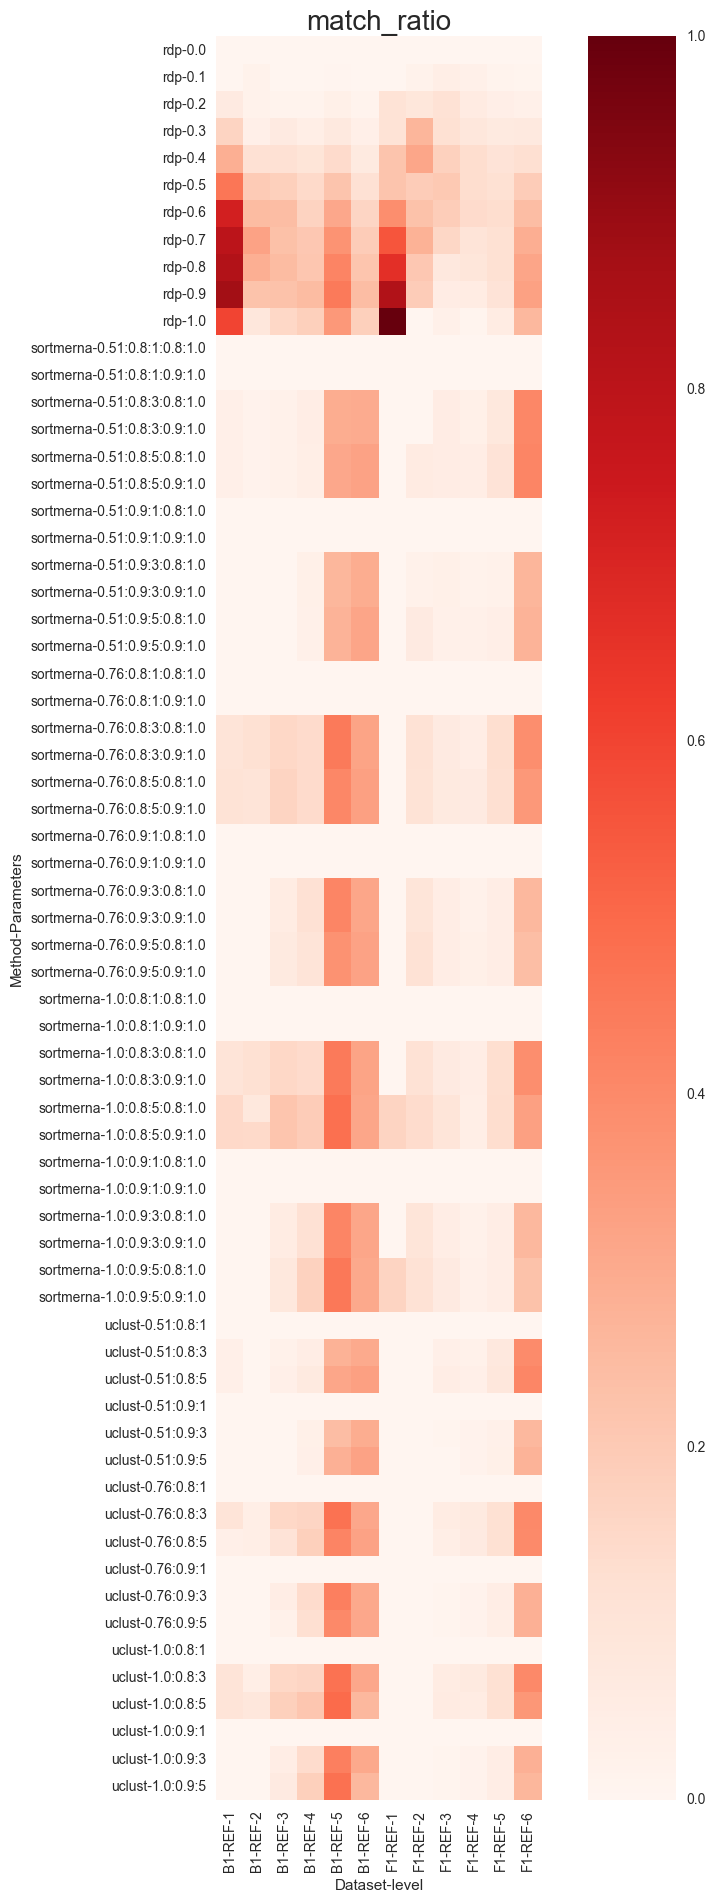

In [15]:
heatmap_from_data_frame(accuracy_results, metric="match_ratio", rows=["Method", "Parameters"], cols=["Dataset", "level"])

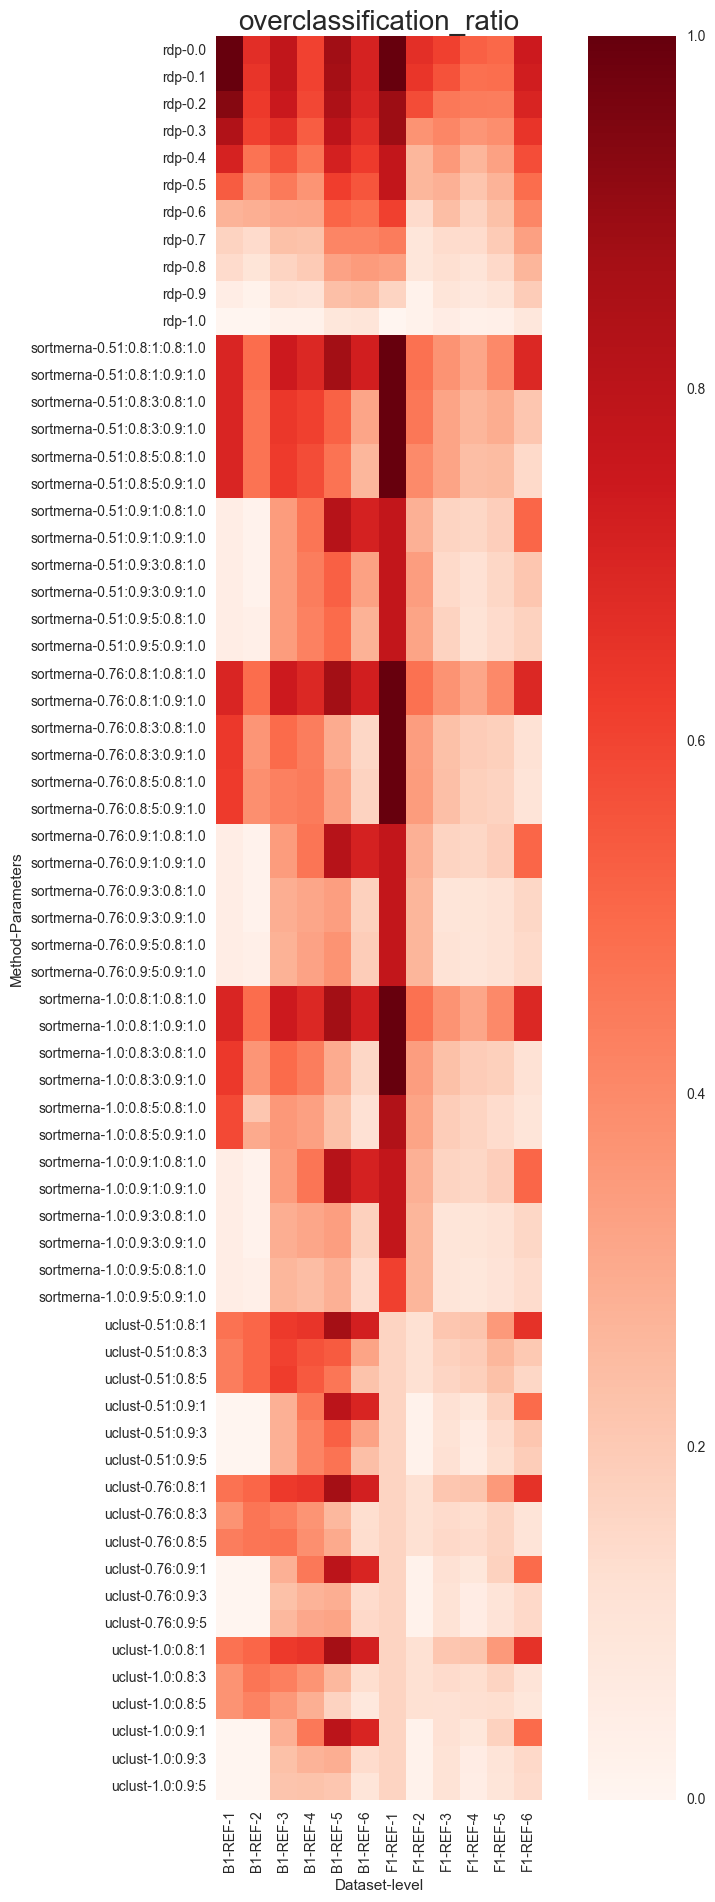

In [9]:
heatmap_from_data_frame(accuracy_results, metric="overclassification_ratio", rows=["Method", "Parameters"], cols=["Dataset", "level"])

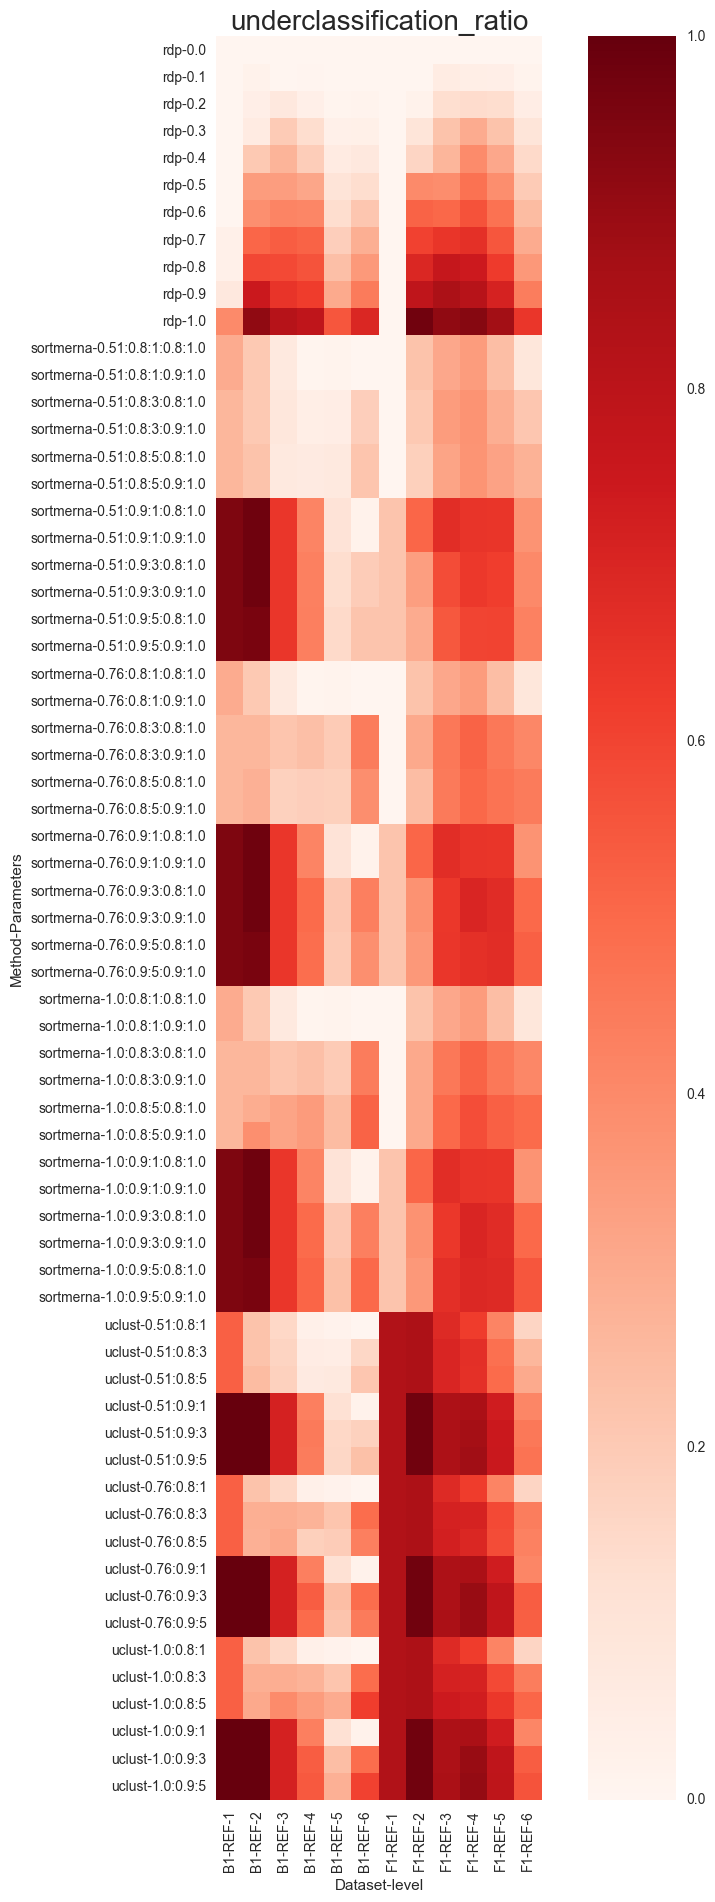

In [10]:
heatmap_from_data_frame(accuracy_results, metric="underclassification_ratio", rows=["Method", "Parameters"], cols=["Dataset", "level"])

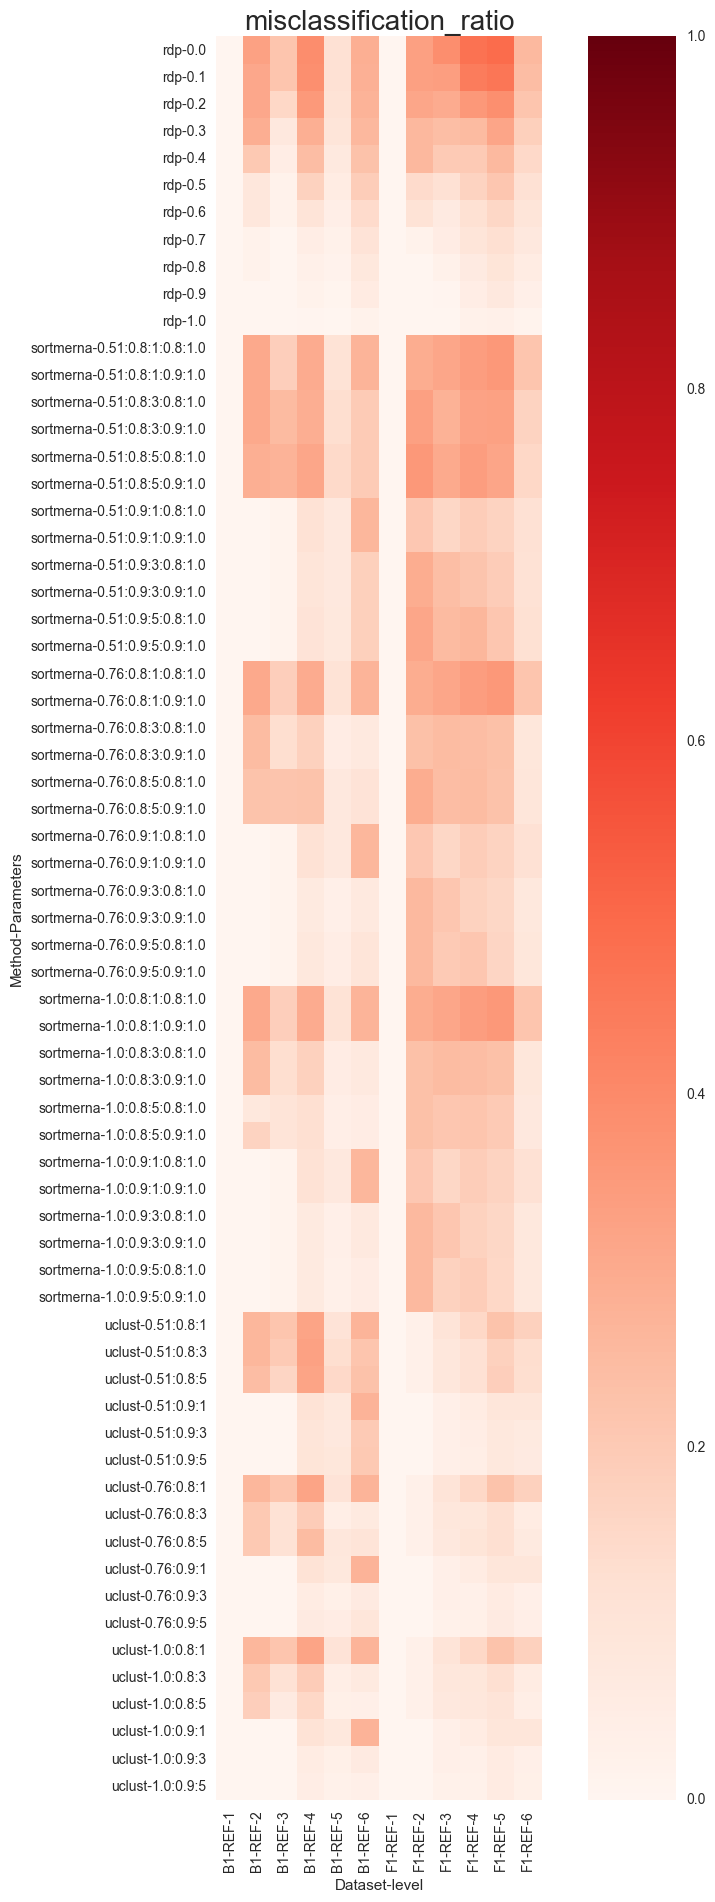

In [11]:
heatmap_from_data_frame(accuracy_results, metric="misclassification_ratio", rows=["Method", "Parameters"], cols=["Dataset", "level"])

## Rank-based statistics comparing the performance of the optimal parameter setting run for each method on each data set.
Rank parameters for each method to determine the best parameter configuration within each method. *Count best* column indicates how many samples a given method achieved within one mean absolute deviation of the best result (which is why they sum to more than the total number of samples).

In [12]:
for method in accuracy_results['Method'].unique():
    top_params = parameter_comparisons(accuracy_results[accuracy_results["level"] == 6], 
                                       method, metrics=["match_ratio"], 
                                       sample_col='Dataset', method_col='Method',
                                       dataset_col='Dataset')
    print(method)
    display(top_params[:5])

rdp


,match_ratio
0.7,6
0.8,6
0.9,6
1.0,5
0.6,4


sortmerna


,match_ratio
0.51:0.8:3:0.8:1.0,6
1.0:0.8:3:0.9:1.0,6
1.0:0.8:5:0.8:1.0,6
1.0:0.8:5:0.9:1.0,6
0.51:0.8:3:0.9:1.0,6


uclust


,match_ratio
0.51:0.8:3,6
0.51:0.8:5,6
0.51:0.9:5,6
0.76:0.8:3,6
0.76:0.8:5,6


Now we rank the top-performing method/parameter combination for each method from family to species level

In [13]:
for dataset in accuracy_results['Dataset'].unique():
    for level in range(4,7):
        method_rank = method_by_dataset(accuracy_results[accuracy_results["level"] == level],
                                        dataset=dataset, sort_field='match_ratio', 
                                        display_fields=("Method", "Parameters", "match_ratio",
                                                       "misclassification_ratio",
                                                       "overclassification_ratio",
                                                       "underclassification_ratio"))
        print("{0} level {1}".format(dataset, level))
        display(method_rank)

B1-REF level 4


,Method,Parameters,match_ratio,misclassification_ratio,overclassification_ratio,underclassification_ratio
725,rdp,1.0,0.268657,0.000000,0.029851,0.701493
779,uclust,1.0:0.9:5,0.238806,0.044776,0.238806,0.477612
754,sortmerna,1.0:0.8:5:0.8:1.0,0.223881,0.089552,0.358209,0.328358


B1-REF level 5


,Method,Parameters,match_ratio,misclassification_ratio,overclassification_ratio,underclassification_ratio
841,uclust,1.0:0.8:5,0.512088,0.028571,0.160440,0.298901
885,sortmerna,1.0:0.8:5:0.9:1.0,0.487414,0.045767,0.247140,0.219680
789,rdp,0.9,0.472527,0.010989,0.226374,0.290110


B1-REF level 6


...

,Method,Parameters,match_ratio,misclassification_ratio,overclassification_ratio,underclassification_ratio
1826,rdp,0.6,0.190476,0.161905,0.152381,0.495238
1880,uclust,1.0:0.8:3,0.085714,0.152381,0.123810,0.638095
1847,sortmerna,0.76:0.8:5:0.8:1.0,0.085714,0.257143,0.180952,0.476190


F1-REF level 5


,Method,Parameters,match_ratio,misclassification_ratio,overclassification_ratio,underclassification_ratio
1987,sortmerna,1.0:0.8:3:0.8:1.0,0.155789,0.256842,0.151579,0.435789
2021,rdp,0.6,0.144068,0.175847,0.224576,0.455508
2140,uclust,1.0:0.8:3,0.135729,0.107784,0.157685,0.598802


F1-REF level 6


,Method,Parameters,match_ratio,misclassification_ratio,overclassification_ratio,underclassification_ratio
2290,sortmerna,0.51:0.8:5:0.8:1.0,0.425448,0.162556,0.140135,0.271861
2259,uclust,0.51:0.8:5,0.415454,0.123180,0.157335,0.304031
2219,rdp,0.9,0.335386,0.033035,0.186450,0.445129
